## Lorenz63 Benchmarks

### config


In [1]:
import torch
import matplotlib.pyplot as plt 
from lorenz import Lorenz63, TimeAveragedFeatures

N = 500
T = 360
spinup = 30
dt = 0.01
params = {
    'sigma':10,
    'beta':8/3,
    'rho':28 
}
l63 = Lorenz63(**params)
x0 = torch.randn((N,3))
r = l63(x0,T,dt)
l63_avg = TimeAveragedFeatures(l63,spinup=spinup)

r_avg = l63_avg(x0,T,dt)


In [2]:
r_avg_norm = (r_avg - r_avg.mean(dim=0))/r_avg.std(dim=0)

In [3]:
from lorenz import get_polynomial_features
spunup0 = get_polynomial_features(r[0,int(spinup/dt):])
t = int(10/dt)

In [4]:
chunks = spunup0.reshape(int((T-spinup)/(dt*t)), t, 9)
chunk_mean = chunks.mean(axis=1)

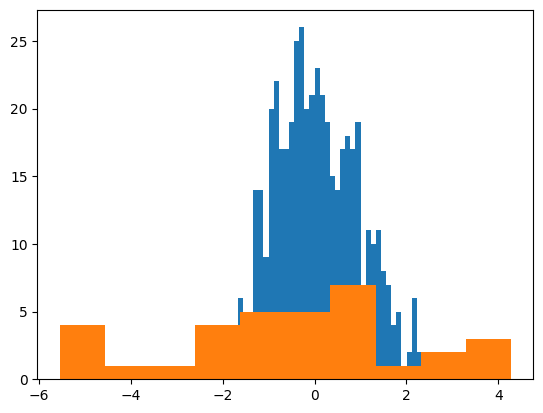

In [5]:

with torch.no_grad():
    plt.hist(r_avg_norm[:,0],bins=50)
    plt.hist(chunk_mean[:,0],bins=10)

In [6]:
from torch.distributions import MultivariateNormal
stats = MultivariateNormal(r_avg_norm.mean(dim=0),torch.cov(r_avg_norm.T))
true_cov = torch.cov(r_avg_norm.T) * (T - spinup)

In [7]:
noise_level = torch.sqrt(torch.linalg.eigh(torch.cov(r_avg.T)).eigenvalues.max())

### calibration

In [8]:
from torch.distributions import MultivariateNormal,Uniform
from abracalibra.forward_model import ForwardModel

priors = {
    'sigma':Uniform(5,15),
    'beta':Uniform(1,5),
    'rho':Uniform(25,30)
} # these are probably too wide priors!


N = 1
x0 = torch.randn((N,3))

def lorenz63(sigma,beta,rho):
    with torch.no_grad():
        l = TimeAveragedFeatures(Lorenz63(sigma.clone(),beta.clone(),rho.clone()),spinup=spinup)
        fwd = l(x0,T,dt)
        return (fwd[0] - r_avg.mean(dim=0))/(r_avg.std(dim=0))

fwd = ForwardModel(lorenz63,vectorized=False)

In [9]:
from abracalibra.history_matching import HistoryMatchingBase
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.emulators import MultiTaskGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.priors import NormalPrior

class HistoryMatchingLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.output_mc_batchshape:
            target_shape = torch.Size((*parameters.shape[:-1], *self.output_mc_batchshape, self.number_of_parameters))
            parameters = parameters.unsqueeze(-2).expand(*target_shape)
            parameters = parameters.reshape(-1, self.number_of_parameters)
        else:
            parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,
            noise_prior=NormalPrior(1,0.001)

        )
        likelihood.noise = 1 
        model = MultiTaskGP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from abracalibra.eki import EnsembleKalmanInversion
from scipy.stats import chi2
from abracalibra.summary import implausibility_multivariate_distr
parameters = ['sigma','beta','rho']
def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

priors = {
    'sigma':Uniform(9,11),
    'beta':Uniform(2,3),
    'rho':Uniform(25,30)
} # th
cutoff = chi2(stats.mean.shape[0]).ppf(0.95)
hm = HistoryMatchingLorenz(parameters,priors,stats,ensemble_size=30,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(3)

Step 0 Loss: 310.86651611328125
Step 1 Loss: 297.0405578613281
Step 2 Loss: 287.5877380371094
Step 3 Loss: 279.29534912109375
Step 4 Loss: 269.9947204589844
Step 5 Loss: 260.32781982421875
Step 6 Loss: 251.2029266357422
Step 7 Loss: 243.0415496826172
Step 8 Loss: 235.7134552001953
Step 9 Loss: 228.7664794921875
Step 10 Loss: 221.85604858398438
Step 11 Loss: 214.96031188964844
Step 12 Loss: 208.2672119140625
Step 13 Loss: 201.9755859375
Step 14 Loss: 196.1548309326172
Step 15 Loss: 190.70423889160156
Step 16 Loss: 185.4304656982422
Step 17 Loss: 180.18685913085938
Step 18 Loss: 174.95335388183594
Step 19 Loss: 169.80690002441406
Step 20 Loss: 164.83468627929688
Step 21 Loss: 160.06297302246094
Step 22 Loss: 155.4393310546875
Step 23 Loss: 150.87319946289062
Step 24 Loss: 146.29905700683594
Step 25 Loss: 141.712890625
Step 26 Loss: 137.15899658203125
Step 27 Loss: 132.6884765625
Step 28 Loss: 128.32017517089844
Step 29 Loss: 124.03097534179688
Step 30 Loss: 119.7800064086914
Step 31 Loss

In [11]:
hm.nroy(torch.tensor([10,8/3,28]),1)

tensor([True])

In [12]:
hm.nroy(torch.tensor([10,8/3,28]),2)


tensor([True])

In [13]:
hm.nroy(torch.tensor([10,8/3,28]),3)

tensor([True])

In [16]:
hm.estimate_nroy_volume(1)

tensor(0.0063)

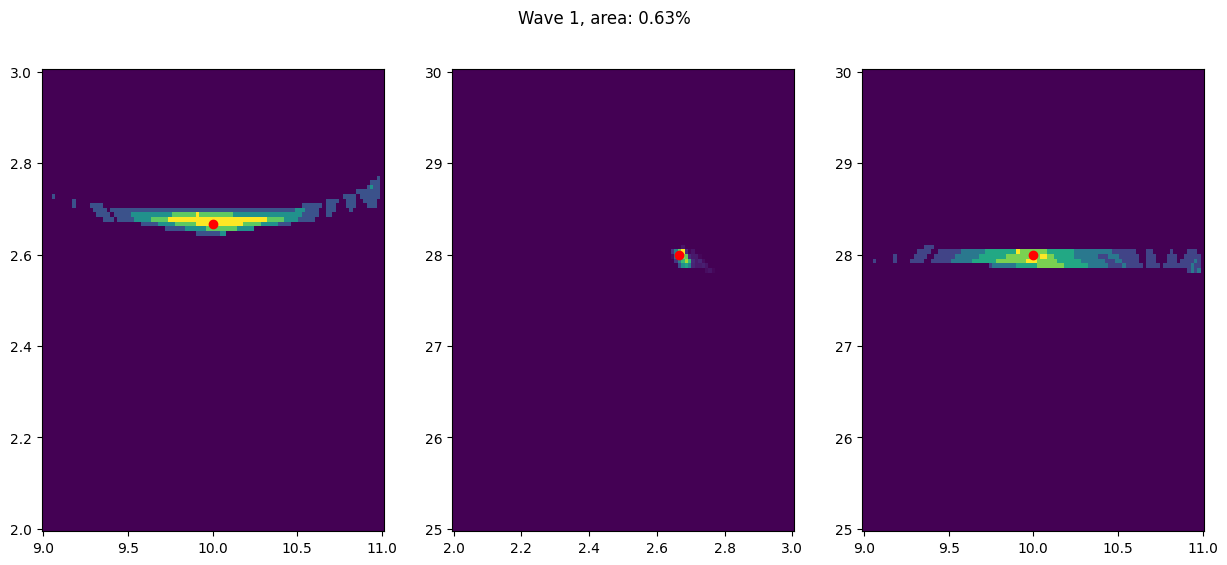

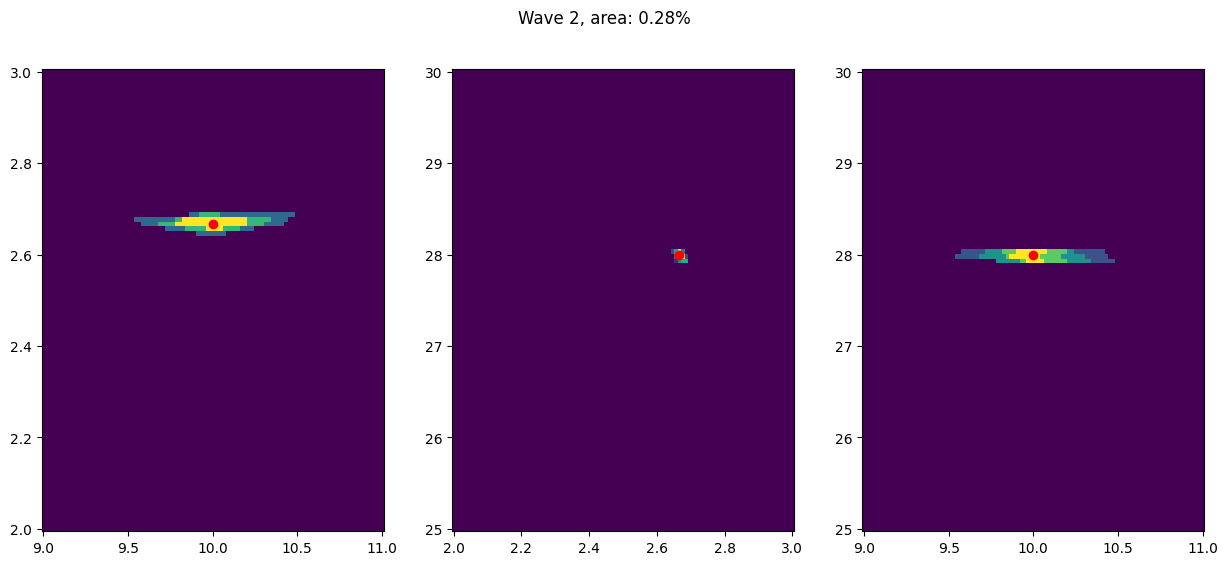

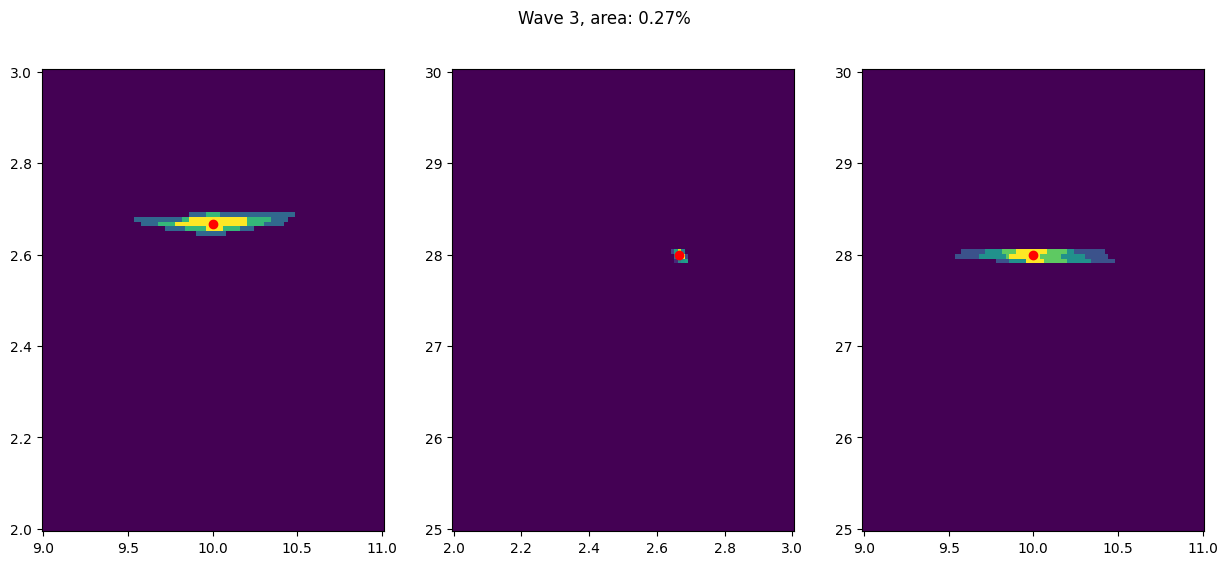

In [21]:
import matplotlib.pyplot as plt
for wave in range(1,4):
    nroy,coords = hm.nroy_over_support(wave,return_coords=True)
    area = hm.estimate_nroy_volume(wave)
    fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,6))
    fig.suptitle(f'Wave {wave}, area: {area.item()*100:.2f}%')
    X,Y = torch.meshgrid(coords[0],coords[1],indexing='xy')
    ax1.pcolormesh(X,Y,nroy.sum(dim=2).T/100)
    ax1.scatter(params['sigma'],params['beta'],color='r')

    X,Y = torch.meshgrid(coords[1],coords[2],indexing='xy')
    ax2.pcolormesh(X,Y,nroy.sum(dim=0).T/100)
    ax2.scatter(params['beta'],params['rho'],color='r')
    X,Y = torch.meshgrid(coords[0],coords[2],indexing='xy')
    ax3.pcolormesh(X,Y,nroy.sum(dim=1).T/100)
    ax3.scatter(params['sigma'],params['rho'],color='r')

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

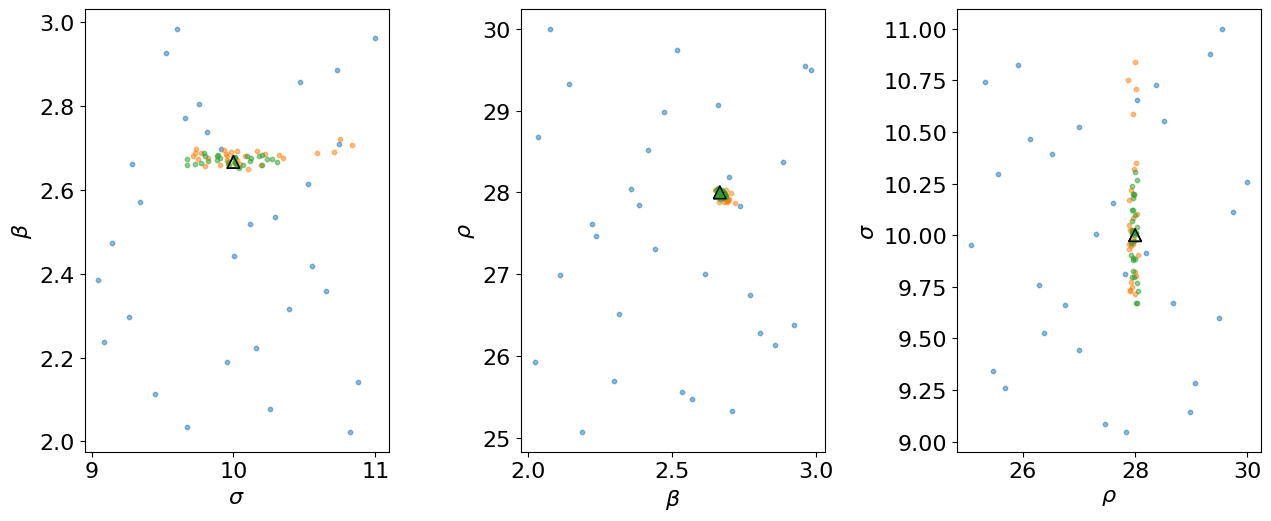

In [25]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in hm.params:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(params['sigma'],params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(params['beta'],params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(params['rho'],params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_hm.png',dpi=300) 

In [31]:
em = hm.emulators[-1]
X,Y,Z = torch.meshgrid(*coords,indexing='ij')
points = torch.stack([X,Y,Z],dim=-1).reshape(-1,3)

In [ ]:
from gpytorch.settings import fast_pred_var
with torch.no_grad(), fast_pred_var():
    predictions = em(points)


## Ensemble Kalman Inversion (L63)

In [22]:
from abracalibra.eki import EnsembleKalmanInversion

eki = EnsembleKalmanInversion(parameters,priors,stats,ensemble_size=30,forward=fwd)
eki.calibrate(3)

tensor([ 9.9833,  2.6676, 28.0033], grad_fn=<MeanBackward1>)

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

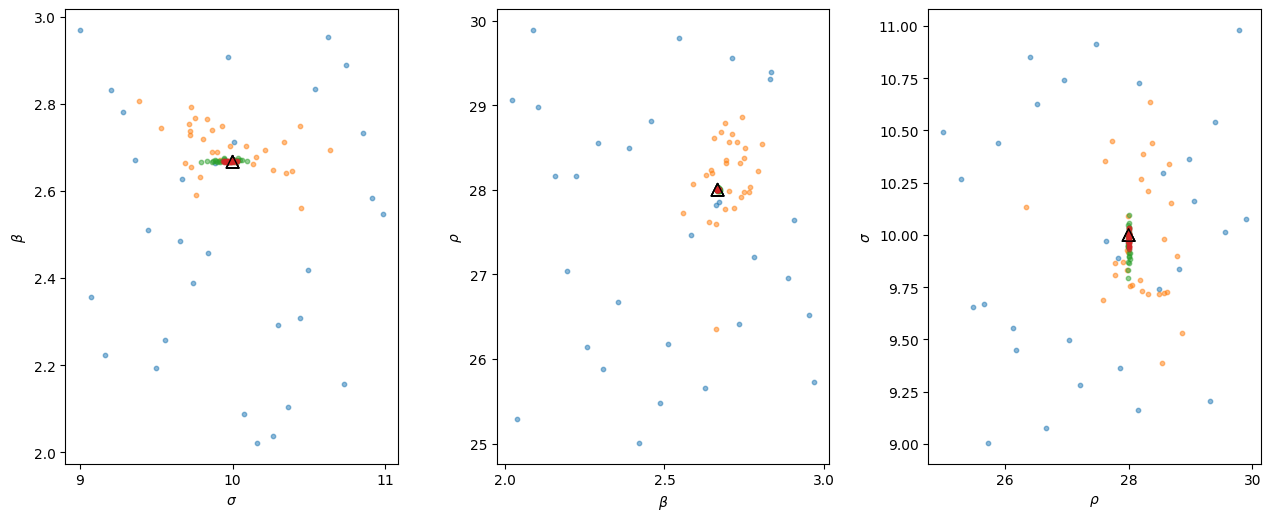

In [23]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in eki.parameters:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(params['sigma'],params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(params['beta'],params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(params['rho'],params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_eki.png',dpi=300) 